--- ANALYSE ALM : BANQUE DES CARAÏBES ---
                Produit  Valeur Nominale  Valeur Actuelle (NPV)  Sensibilité (ModDur)
 Crédits Conso (Sorefi)       80000000.0           8.765363e+07              2.001838
   Prêts Immo Taux Fixe      250000000.0           2.714646e+08              6.929824
Crédit-Bail Entreprises      120000000.0           1.313817e+08              3.421873

NPV Totale du Bilan: 490.50 M€
Sensibilité Globale: 5.11
Risque financier pour +100bps: -25.06 M€
----------------------------------------
STRATÉGIE DE COUVERTURE :
Notionnel de Swap (10Y) à souscrire : 294.85 M€


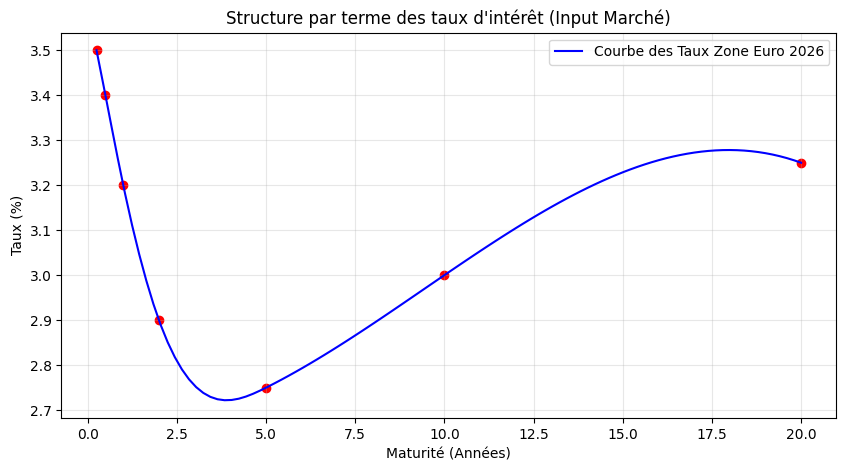

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

class BanqueCaraibesALM:
    def __init__(self):
        # 1. DONNÉES DE MARCHÉ RÉELLES (ESTIMATIONS 2026)
        # Ces taux reflètent la courbe des taux de la Zone Euro (OAT / EURIBOR)
        self.market_data = {
            0.25: 0.0350,  # Euribor 3 mois (3.50%)
            0.5:  0.0340,  # Euribor 6 mois
            1:    0.0320,  # Taux 1 an
            2:    0.0290,  # Taux 2 ans (Inversion légère de courbe)
            5:    0.0275,  # Taux 5 ans
            10:   0.0300,  # Taux 10 ans
            20:   0.0325   # Taux 20 ans
        }
        
        self.years = np.array(list(self.market_data.keys()))
        self.rates = np.array(list(self.market_data.values()))
        self.yield_curve = interp1d(self.years, self.rates, kind='cubic', fill_value="extrapolate")

    def get_rate(self, t):
        return self.yield_curve(t)

    def compute_loan_metrics(self, principal, coupon_rate, years, freq=12):
        """Calcule NPV et Duration pour un prêt amortissable (mensualités constantes)."""
        n_periods = int(years * freq)
        t = np.arange(1, n_periods + 1) / freq
        
        # Calcul de la mensualité constante (Formule de l'annuité)
        periodic_rate = coupon_rate / freq
        monthly_payment = principal * (periodic_rate / (1 - (1 + periodic_rate)**-n_periods))
        
        # Actualisation flux par flux avec le taux de la courbe correspondant à chaque maturité
        discount_rates = self.get_rate(t)
        df = (1 + discount_rates/freq)**-(t * freq)
        
        pv_flux = monthly_payment * df
        npv = np.sum(pv_flux)
        
        # Duration de Macaulay
        mac_dur = np.sum(t * pv_flux) / npv
        # Duration Modifiée
        mod_dur = mac_dur / (1 + discount_rates.mean()/freq)
        
        return npv, mod_dur

    def run_analysis(self):
        # 2. PORTEFEUILLE FICTIF MAIS RÉALISTE POUR LA BANQUE
        portfolio = [
            {"label": "Crédits Conso (Sorefi)", "amount": 80e6, "rate": 0.075, "years": 4},
            {"label": "Prêts Immo Taux Fixe", "amount": 250e6, "rate": 0.042, "years": 15},
            {"label": "Crédit-Bail Entreprises", "amount": 120e6, "rate": 0.055, "years": 7}
        ]
        
        results = []
        for item in portfolio:
            npv, m_dur = self.compute_loan_metrics(item['amount'], item['rate'], item['years'])
            results.append({
                "Produit": item['label'],
                "Valeur Nominale": item['amount'],
                "Valeur Actuelle (NPV)": npv,
                "Sensibilité (ModDur)": m_dur
            })
            
        df = pd.DataFrame(results)
        
        # 3. CALCUL DU GAP DE DURÉE
        total_npv = df["Valeur Actuelle (NPV)"].sum()
        agg_dur = (df["Valeur Actuelle (NPV)"] * df["Sensibilité (ModDur)"]).sum() / total_npv
        
        # 4. SIMULATION D'IMMUNISATION PAR SWAP
        # Imaginons que la banque veuille couvrir 100% de sa sensibilité
        # Un Swap de 10 ans a une ModDur d'environ 8.5
        swap_mod_dur = 8.5 
        notionnel_hedge = (agg_dur * total_npv) / swap_mod_dur
        
        print("--- ANALYSE ALM : BANQUE DES CARAÏBES ---")
        print(df.to_string(index=False))
        print(f"\nNPV Totale du Bilan: {total_npv/1e6:.2f} M€")
        print(f"Sensibilité Globale: {agg_dur:.2f}")
        print(f"Risque financier pour +100bps: {-(agg_dur * 0.01 * total_npv)/1e6:.2f} M€")
        print("-" * 40)
        print(f"STRATÉGIE DE COUVERTURE :")
        print(f"Notionnel de Swap (10Y) à souscrire : {notionnel_hedge/1e6:.2f} M€")
        
        # 5. GRAPHique DE LA COURBE DES TAUX
        t_plot = np.linspace(0.25, 20, 100)
        plt.figure(figsize=(10,5))
        plt.plot(t_plot, self.yield_curve(t_plot)*100, label="Courbe des Taux Zone Euro 2026", color='blue')
        plt.scatter(self.years, self.rates*100, color='red')
        plt.title("Structure par terme des taux d'intérêt (Input Marché)")
        plt.xlabel("Maturité (Années)")
        plt.ylabel("Taux (%)")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

# Exécution
session = BanqueCaraibesALM()
session.run_analysis()